Error Cuadrático Medio (Observación vs Real): 2.9979
Error Cuadrático Medio (Kalman vs Real): 21.1630


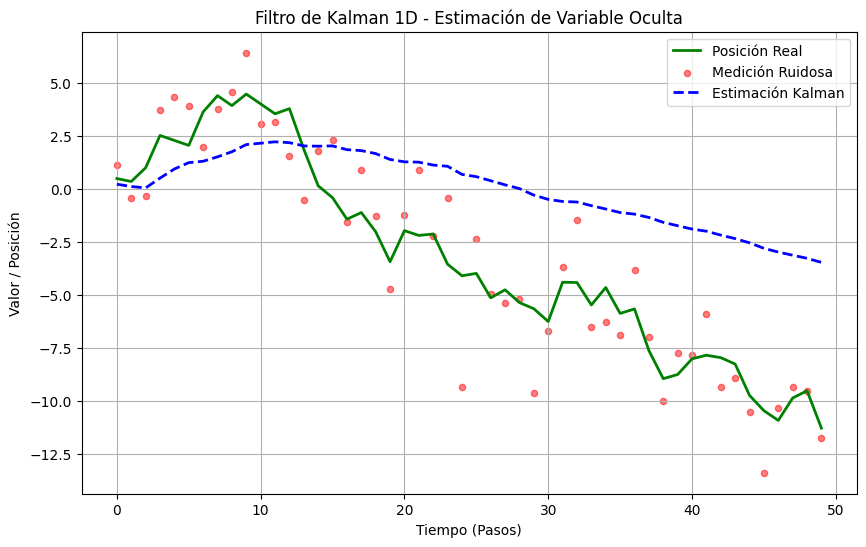

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import os

# Asegurar que la carpeta media exista (si se ejecuta localmente)
os.makedirs('../media', exist_ok=True)

# 1. Generar datos simulados
np.random.seed(42) # Para reproducibilidad
n_steps = 50
real = np.cumsum(np.random.randn(n_steps)) # Posición real (caminata aleatoria)
noise = np.random.normal(0, 2, size=n_steps)
observed = real + noise # Medición ruidosa

# 2. Inicialización del filtro de Kalman (1D)
estimate = []
P = 1.0       # Covarianza inicial del error
x_hat = 0.0   # Estimación inicial del estado
Q = 0.001     # Varianza del ruido del proceso (modelo)
R = 4.0       # Varianza del ruido de la medición

# 3. Ciclo del Filtro de Kalman
for z in observed:
    # --- Etapa de Predicción ---
    x_hat_prior = x_hat
    P_prior = P + Q

    # --- Etapa de Corrección ---
    K = P_prior / (P_prior + R) # Ganancia de Kalman
    x_hat = x_hat_prior + K * (z - x_hat_prior)
    P = (1 - K) * P_prior

    estimate.append(x_hat)

# 4. Análisis de Errores
mse_observed = mean_squared_error(real, observed)
mse_kalman = mean_squared_error(real, estimate)
print(f"Error Cuadrático Medio (Observación vs Real): {mse_observed:.4f}")
print(f"Error Cuadrático Medio (Kalman vs Real): {mse_kalman:.4f}")

# 5. Visualización y guardado
plt.figure(figsize=(10, 6))
plt.plot(real, label='Posición Real', color='green', linewidth=2)
plt.scatter(range(n_steps), observed, label='Medición Ruidosa', color='red', alpha=0.5, s=20)
plt.plot(estimate, label='Estimación Kalman', color='blue', linewidth=2, linestyle='dashed')

plt.title('Filtro de Kalman 1D - Estimación de Variable Oculta')
plt.xlabel('Tiempo (Pasos)')
plt.ylabel('Valor / Posición')
plt.legend()
plt.grid(True)

# Guardar en la carpeta media
plt.savefig('../media/grafico_resultado.png')
plt.show()